# Build an adjacency map, solution

Load code and data for countries, cities, and roads, which form a symmetric weighted graph.

Turn those data sets into an adjacency map

Print a map of Europe 



In [1]:
import os
#print(os.getcwd())

from roadbox import Country, City, Road
from roadbox import show_map, show_path

In [2]:
with open(f"countries.py", 'r', encoding="utf8") as file:
    countries = eval(file.read())

with open(f"cities.py", 'r', encoding="utf8") as file:
    cities = eval(file.read())

with open(f"roads.py", 'r', encoding="utf8") as file:
    roads = eval(file.read())

with open(f"example_paths.py", 'r', encoding="utf8") as file:
    example_paths = eval(file.read())

To use the following code, if you have not done so already, install the basemap package via the command line interface: 

```conda install basemap```

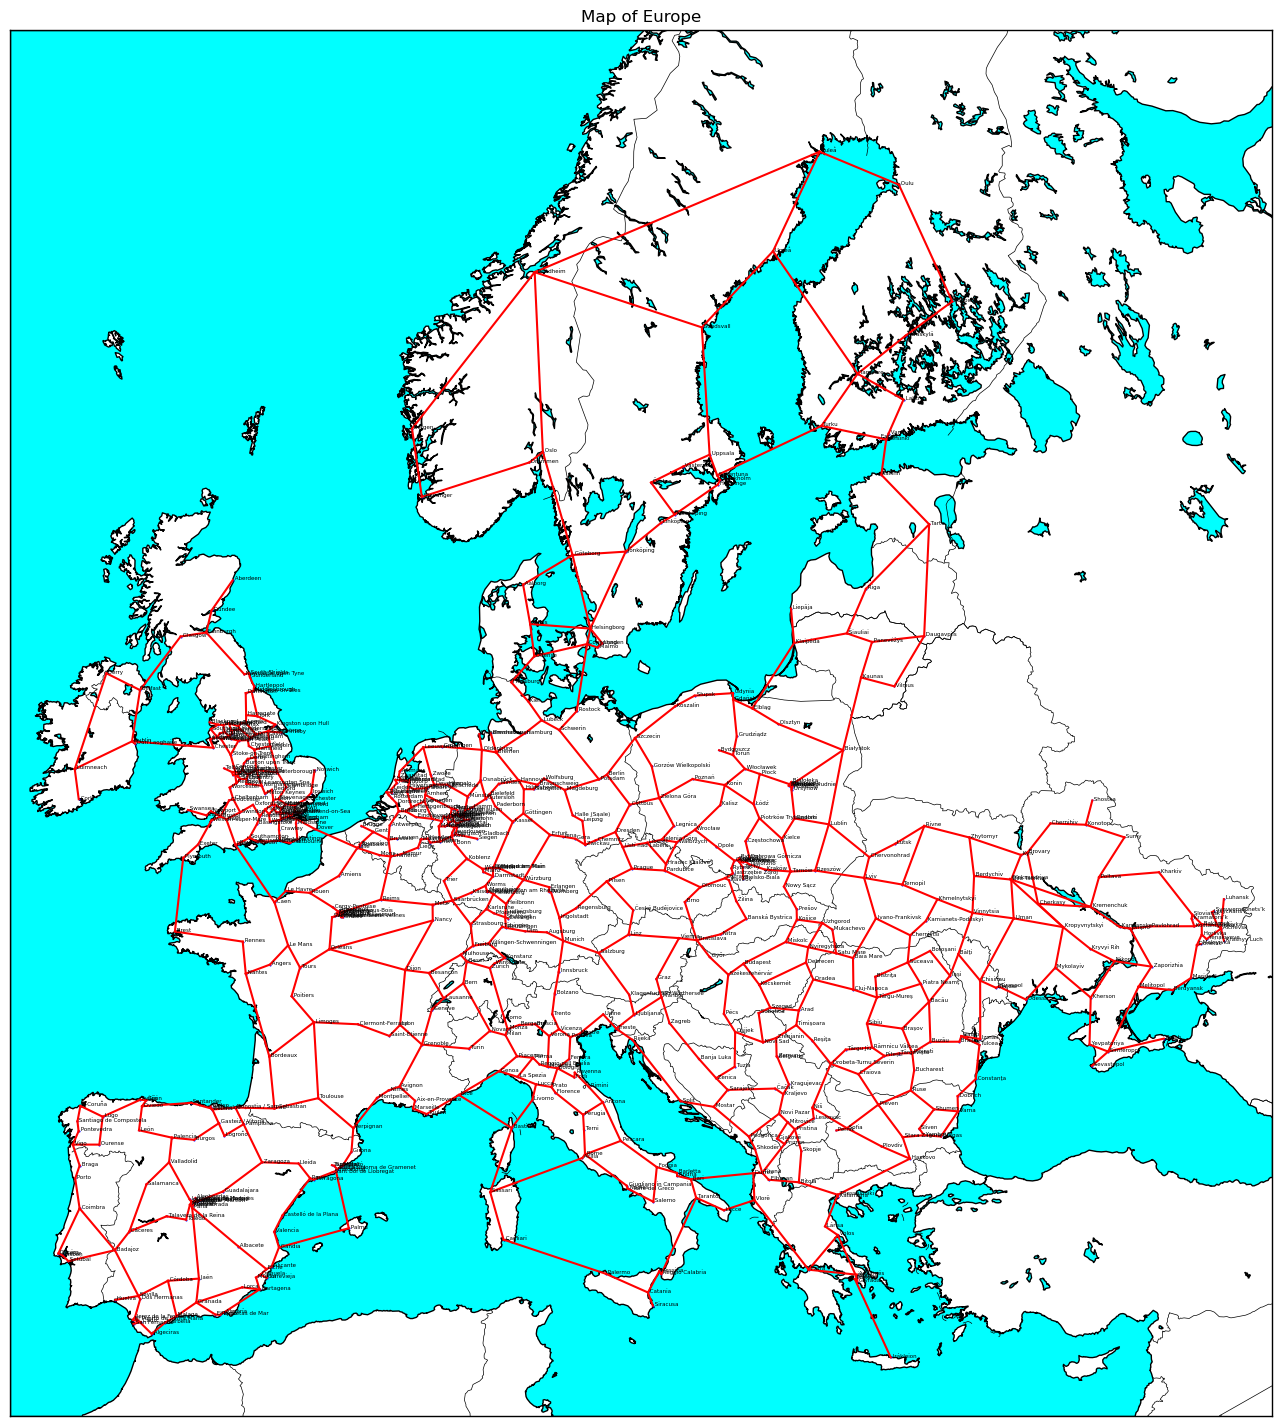

In [3]:
show_map(cities, roads)

path length in number of nodes: 11


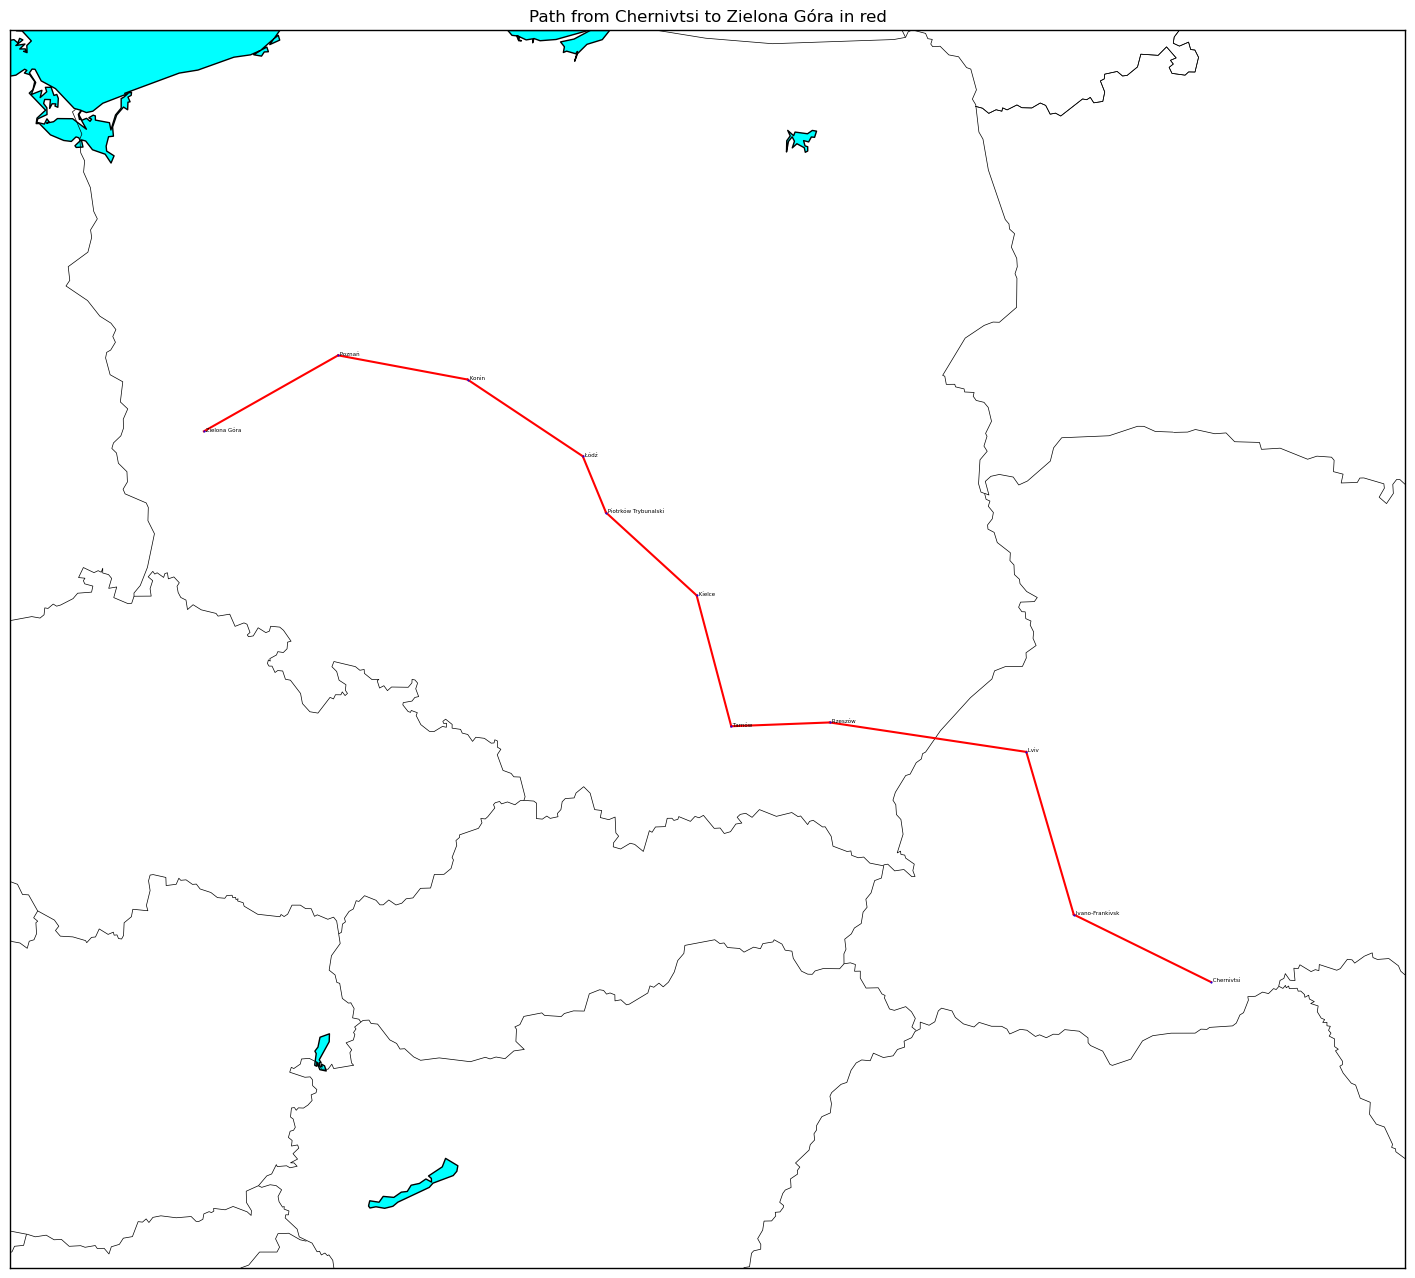

In [4]:
show_path(cities, example_paths[0])

### Adjacency map
In order to work efficiently with the data, you need to turn the list of roads into adjacency map, which is a dictionary of dictionaries.

If the adjacency map is implemented correcly, you can querry for the length of the road between cities *a* and *b* it like this:
```python
import math
if a in adjacency_map and b in adjacency_map[a]:
    distance = adjacency_map[a][b]
else:
    distance = math.inf # assuming that the default value is infinity
```

Our road network forms a symmetric weighted graph. Whenever you enter a distance from *a* to *b*, you need to enter the same distance from *b* to *a*.

```python
adjacency_map[road.a][road.b] = road.distance 
adjacency_map[road.b][road.a] = road.distance
```



In [7]:
def create_map(roads):
    '''creates an adjacency map'''
    adjacency_map = {}

    for r in roads:
        
        if not r.a in adjacency_map:
            adjacency_map[r.a] = {}
        adjacency_map[r.a][r.b] = r.distance

        if not r.b in adjacency_map:
            adjacency_map[r.b] = {}
        adjacency_map[r.b][r.a] = r.distance

    return adjacency_map


def verify_map(roads, adjacency_map):
    '''verifies that all roads are properly entered into
    the adjacency map'''
    success = True
    for road in roads:
        if (not road.a in adjacency_map or 
            not road.b in adjacency_map or
            not road.a in adjacency_map[road.b] or 
            not road.b in adjacency_map[road.a]):
            print("problem with indices of road " + str(road))
            success = False
        else:
            if (not road.distance == adjacency_map[road.a][road.b] or 
                not road.distance == adjacency_map[road.b][road.a]):
                print("problem with distance of road " + str(road))
                success = False
    if success:
        print("verification successful")
    else:
        print("verification FAILED")

adjacency_map = create_map(roads)

verify_map(roads, adjacency_map)

verification successful


Next, an example of how to access a value from an adjacency_map even when the value is not stored

In [15]:
def get_distance(adjacency_map, a, b):

    if (a in adjacency_map and b in adjacency_map[a]):
        return adjacency_map[a][b]
    else:
        return float('inf')

print(get_distance(adjacency_map, 10, 100))

inf
